In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

PROCESSED_DIR = os.path.join("..", config.PROCESSED_DATA_DIR)
FEATURES_DIR  = os.path.join("..", config.FEATURES_DATA_DIR)
PLOTS_DIR     = os.path.join("..", config.OUTPUTS_PLOTS)
CITIES        = list(config.CITIES.keys())
DAYTIME_THR   = config.DAYTIME_THR

os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,    exist_ok=True)

print("✅ Imports ready")
print(f"   Features will be saved to : {FEATURES_DIR}")

✅ Imports ready
   Features will be saved to : ..\data/features


In [2]:
city_dfs = {}

print("📂 Loading processed CSVs...\n")
for city in CITIES:
    path = os.path.join(PROCESSED_DIR, f"{city}_processed.csv")
    df   = pd.read_csv(path, index_col="datetime", parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    city_dfs[city] = df
    print(f"  ✅ {city:<14}  shape={df.shape}")

print(f"\n📋 Columns available: {list(city_dfs['riyadh'].columns)}")

📂 Loading processed CSVs...

  ✅ riyadh          shape=(26280, 10)
  ✅ cairo           shape=(26280, 10)
  ✅ istanbul        shape=(26280, 10)
  ✅ new_delhi       shape=(26280, 10)
  ✅ dubai           shape=(26280, 10)
  ✅ london          shape=(26280, 10)
  ✅ sydney          shape=(26280, 10)
  ✅ tokyo           shape=(26280, 10)
  ✅ los_angeles     shape=(26280, 10)
  ✅ nairobi         shape=(26280, 10)

📋 Columns available: ['GHI', 'temperature', 'wind_speed', 'humidity', 'clear_sky_ghi', 'precipitation', 'pressure', 'clearness_index', 'local_hour', 'utc_offset']


In [3]:
def add_cyclical_features(df: pd.DataFrame, utc_offset: float) -> pd.DataFrame:
    """
    Encode time features as sin/cos pairs so the model
    understands that hour 23 and hour 0 are adjacent,
    and December and January are adjacent.

    Raw integers (hour=0,1,...,23) create a false discontinuity
    at midnight. Sin/cos encoding removes this completely.
    """
    df = df.copy()

    # Local time index
    local_idx = df.index + pd.Timedelta(hours=utc_offset)

    hour   = local_idx.hour
    doy    = local_idx.dayofyear
    month  = local_idx.month
    minute = local_idx.minute

    # Hour (period = 24)
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

    # Day of year (period = 365)
    df["doy_sin"]  = np.sin(2 * np.pi * doy / 365.0)
    df["doy_cos"]  = np.cos(2 * np.pi * doy / 365.0)

    # Month (period = 12)
    df["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * month / 12.0)

    return df


UTC_OFFSETS = {
    "riyadh": 3, "cairo": 2, "istanbul": 3,
    "new_delhi": 5.5, "dubai": 4, "london": 0,
    "sydney": 10, "tokyo": 9, "los_angeles": -8, "nairobi": 3,
}

print("🔄 Adding cyclical time encodings...\n")
for city in CITIES:
    offset         = UTC_OFFSETS[city]
    city_dfs[city] = add_cyclical_features(city_dfs[city], offset)
    added          = ["hour_sin","hour_cos","doy_sin","doy_cos","month_sin","month_cos"]
    print(f"  ✅ {city:<14}  added: {added}")

print("\n✅ Cyclical encodings done — no raw hour/doy integers needed")

🔄 Adding cyclical time encodings...

  ✅ riyadh          added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ cairo           added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ istanbul        added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ new_delhi       added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ dubai           added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ london          added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ sydney          added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ tokyo           added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ los_angeles     added: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
  ✅ nairobi         added: ['hour_sin', 'hour_cos', 'doy_sin', 

In [4]:
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48]

# Features to lag — GHI is most important, clearness_index second
LAG_FEATURES = ["GHI", "clearness_index", "clear_sky_ghi"]


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create lag features: value of each feature at t-k hours.

    These are the most powerful predictors for solar forecasting
    because solar irradiance is strongly autocorrelated (ACF showed
    significant correlation up to 48 hours in EDA).
    """
    df = df.copy()
    for col in LAG_FEATURES:
        for lag in LAG_HOURS:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df


print("🔄 Adding lag features...\n")
lag_col_names = [f"{c}_lag{l}" for c in LAG_FEATURES for l in LAG_HOURS]
print(f"  Lag columns to create : {len(lag_col_names)}")
print(f"  {lag_col_names}\n")

for city in CITIES:
    city_dfs[city] = add_lag_features(city_dfs[city])
    print(f"  ✅ {city:<14}  shape now = {city_dfs[city].shape}")

print(f"\n✅ Lag features added — {len(lag_col_names)} new columns per city")

🔄 Adding lag features...

  Lag columns to create : 21
  ['GHI_lag1', 'GHI_lag2', 'GHI_lag3', 'GHI_lag6', 'GHI_lag12', 'GHI_lag24', 'GHI_lag48', 'clearness_index_lag1', 'clearness_index_lag2', 'clearness_index_lag3', 'clearness_index_lag6', 'clearness_index_lag12', 'clearness_index_lag24', 'clearness_index_lag48', 'clear_sky_ghi_lag1', 'clear_sky_ghi_lag2', 'clear_sky_ghi_lag3', 'clear_sky_ghi_lag6', 'clear_sky_ghi_lag12', 'clear_sky_ghi_lag24', 'clear_sky_ghi_lag48']

  ✅ riyadh          shape now = (26280, 37)
  ✅ cairo           shape now = (26280, 37)
  ✅ istanbul        shape now = (26280, 37)
  ✅ new_delhi       shape now = (26280, 37)
  ✅ dubai           shape now = (26280, 37)
  ✅ london          shape now = (26280, 37)
  ✅ sydney          shape now = (26280, 37)
  ✅ tokyo           shape now = (26280, 37)
  ✅ los_angeles     shape now = (26280, 37)
  ✅ nairobi         shape now = (26280, 37)

✅ Lag features added — 21 new columns per city


In [5]:
ROLLING_WINDOWS = [3, 6, 24]   # hours
ROLLING_FEATURES = ["GHI", "clearness_index"]


def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rolling mean and std capture local trends and volatility.

    - 3h  rolling mean  → very recent trend (cloud passage)
    - 6h  rolling mean  → half-day trend
    - 24h rolling mean  → previous full day average
    - std               → irradiance volatility (cloudy vs clear days)
    """
    df = df.copy()
    for col in ROLLING_FEATURES:
        for w in ROLLING_WINDOWS:
            df[f"{col}_roll{w}_mean"] = (
                df[col].rolling(window=w, min_periods=1).mean()
            )
            df[f"{col}_roll{w}_std"] = (
                df[col].rolling(window=w, min_periods=1).std().fillna(0)
            )
    return df


print("🔄 Adding rolling statistics...\n")
roll_cols = [
    f"{c}_roll{w}_{s}"
    for c in ROLLING_FEATURES
    for w in ROLLING_WINDOWS
    for s in ["mean", "std"]
]
print(f"  Rolling columns to create : {len(roll_cols)}")
print(f"  {roll_cols}\n")

for city in CITIES:
    city_dfs[city] = add_rolling_features(city_dfs[city])
    print(f"  ✅ {city:<14}  shape now = {city_dfs[city].shape}")

print(f"\n✅ Rolling features added — {len(roll_cols)} new columns per city")

🔄 Adding rolling statistics...

  Rolling columns to create : 12
  ['GHI_roll3_mean', 'GHI_roll3_std', 'GHI_roll6_mean', 'GHI_roll6_std', 'GHI_roll24_mean', 'GHI_roll24_std', 'clearness_index_roll3_mean', 'clearness_index_roll3_std', 'clearness_index_roll6_mean', 'clearness_index_roll6_std', 'clearness_index_roll24_mean', 'clearness_index_roll24_std']

  ✅ riyadh          shape now = (26280, 49)
  ✅ cairo           shape now = (26280, 49)
  ✅ istanbul        shape now = (26280, 49)
  ✅ new_delhi       shape now = (26280, 49)
  ✅ dubai           shape now = (26280, 49)
  ✅ london          shape now = (26280, 49)
  ✅ sydney          shape now = (26280, 49)
  ✅ tokyo           shape now = (26280, 49)
  ✅ los_angeles     shape now = (26280, 49)
  ✅ nairobi         shape now = (26280, 49)

✅ Rolling features added — 12 new columns per city


In [6]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Interaction terms capture combined effects that individual
    features miss:

    - clear_sky_ghi × clearness_index  → best single predictor of GHI
      (theoretical max × fraction actually received)
    - temperature × humidity           → heat-humidity stress index
    - wind_speed × humidity            → evaporation/cooling effect
    - GHI_lag24 × clearness_index      → yesterday's solar × today's clarity
    """
    df = df.copy()

    # Most powerful: theoretical × actual fraction
    df["clearsky_x_kt"] = df["clear_sky_ghi"] * df["clearness_index"]

    # Temperature-humidity interaction
    df["temp_x_humidity"] = df["temperature"] * df["humidity"]

    # Wind-humidity interaction
    df["wind_x_humidity"] = df["wind_speed"] * df["humidity"]

    # Yesterday's GHI × today's clearness
    if "GHI_lag24" in df.columns:
        df["lag24_x_kt"] = df["GHI_lag24"] * df["clearness_index"]

    # Recent trend ratio: current vs 24h rolling mean
    if "GHI_roll24_mean" in df.columns:
        roll24 = df["GHI_roll24_mean"].replace(0, np.nan)
        df["ghi_trend_ratio"] = (df["GHI"] / roll24).fillna(1.0).clip(0, 5)

    return df


print("🔄 Adding interaction features...\n")
for city in CITIES:
    city_dfs[city] = add_interaction_features(city_dfs[city])
    print(f"  ✅ {city:<14}  shape now = {city_dfs[city].shape}")

print("\n✅ Interaction features added")

🔄 Adding interaction features...

  ✅ riyadh          shape now = (26280, 54)
  ✅ cairo           shape now = (26280, 54)
  ✅ istanbul        shape now = (26280, 54)
  ✅ new_delhi       shape now = (26280, 54)
  ✅ dubai           shape now = (26280, 54)
  ✅ london          shape now = (26280, 54)
  ✅ sydney          shape now = (26280, 54)
  ✅ tokyo           shape now = (26280, 54)
  ✅ los_angeles     shape now = (26280, 54)
  ✅ nairobi         shape now = (26280, 54)

✅ Interaction features added


In [7]:
def solar_elevation_angle(
    doy: np.ndarray,
    hour: np.ndarray,
    lat_deg: float
) -> np.ndarray:
    """
    Approximate solar elevation angle in degrees.

    This is a physics-based feature — it tells the model exactly
    how high the sun is in the sky at each timestamp, which directly
    controls the maximum possible irradiance.

    Formula: simplified declination + hour angle approach.
    Accurate to ~1° for our purposes.
    """
    lat  = np.radians(lat_deg)
    decl = np.radians(23.45 * np.sin(np.radians(360 / 365 * (doy - 81))))
    ha   = np.radians(15.0 * (hour - 12.0))    # hour angle
    elev = np.degrees(
        np.arcsin(
            np.sin(lat) * np.sin(decl)
            + np.cos(lat) * np.cos(decl) * np.cos(ha)
        )
    )
    return elev.clip(0, 90)                     # negative = below horizon → 0


def add_solar_geometry(
    df: pd.DataFrame,
    lat_deg: float,
    utc_offset: float
) -> pd.DataFrame:
    df        = df.copy()
    local_idx = df.index + pd.Timedelta(hours=utc_offset)
    doy       = local_idx.dayofyear.values.astype(float)
    hour      = local_idx.hour.values.astype(float) \
              + local_idx.minute.values.astype(float) / 60.0

    df["solar_elevation"] = solar_elevation_angle(doy, hour, lat_deg)

    # Also: cos of solar zenith angle (used in many irradiance models)
    df["cos_zenith"] = np.cos(np.radians(90 - df["solar_elevation"]))
    return df


print("🔄 Adding solar geometry features...\n")
for city in CITIES:
    lat    = config.CITIES[city]["lat"]
    offset = UTC_OFFSETS[city]
    city_dfs[city] = add_solar_geometry(city_dfs[city], lat, offset)
    elev_max = city_dfs[city]["solar_elevation"].max()
    print(f"  ✅ {city:<14}  max elevation = {elev_max:.1f}°  "
          f"shape = {city_dfs[city].shape}")

print("\n✅ Solar geometry features added")

🔄 Adding solar geometry features...

  ✅ riyadh          max elevation = 88.7°  shape = (26280, 56)
  ✅ cairo           max elevation = 83.4°  shape = (26280, 56)
  ✅ istanbul        max elevation = 72.4°  shape = (26280, 56)
  ✅ new_delhi       max elevation = 81.5°  shape = (26280, 56)
  ✅ dubai           max elevation = 88.2°  shape = (26280, 56)
  ✅ london          max elevation = 61.9°  shape = (26280, 56)
  ✅ sydney          max elevation = 79.6°  shape = (26280, 56)
  ✅ tokyo           max elevation = 77.8°  shape = (26280, 56)
  ✅ los_angeles     max elevation = 79.4°  shape = (26280, 56)
  ✅ nairobi         max elevation = 89.9°  shape = (26280, 56)

✅ Solar geometry features added


In [8]:
def add_daytime_flag(df: pd.DataFrame) -> pd.DataFrame:
    """
    Binary flag: 1 if daytime (GHI > threshold), 0 if night.
    Helps models handle the bimodal distribution of GHI
    (hard zero at night vs continuous distribution during day).
    """
    df = df.copy()
    df["is_daytime"] = (df["GHI"] > DAYTIME_THR).astype(int)
    df["is_daytime_clear_sky"] = (
        df["clear_sky_ghi"] > DAYTIME_THR
    ).astype(int)
    return df


def final_cleanup(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop rows with NaN introduced by lag features (first 48 rows).
    Replace any remaining NaN/inf with 0.
    """
    df = df.copy()
    # Drop the first 48 rows (lag features create NaN there)
    df = df.iloc[48:].copy()
    # Replace inf
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Fill remaining NaN with column median
    for col in df.select_dtypes(include=[np.number]).columns:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
    return df


print("🔄 Adding daytime flag and running final cleanup...\n")
for city in CITIES:
    city_dfs[city] = add_daytime_flag(city_dfs[city])
    before         = len(city_dfs[city])
    city_dfs[city] = final_cleanup(city_dfs[city])
    after          = len(city_dfs[city])
    nulls          = city_dfs[city].isna().sum().sum()
    print(f"  ✅ {city:<14}  rows: {before:,} → {after:,}  "
          f"nulls={nulls}  shape={city_dfs[city].shape}")

print("\n✅ Cleanup complete — all NaN and inf removed")

🔄 Adding daytime flag and running final cleanup...

  ✅ riyadh          rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ cairo           rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ istanbul        rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ new_delhi       rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ dubai           rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ london          rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ sydney          rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ tokyo           rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ los_angeles     rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)
  ✅ nairobi         rows: 26,280 → 26,232  nulls=0  shape=(26232, 58)

✅ Cleanup complete — all NaN and inf removed


In [9]:
print("💾 Saving feature-engineered CSVs...\n")

feature_summary = []
for city in CITIES:
    df       = city_dfs[city]
    out_path = os.path.join(FEATURES_DIR, f"{city}_features.csv")
    df.to_csv(out_path)

    feature_summary.append({
        "city"       : city,
        "rows"       : len(df),
        "total_cols" : len(df.columns),
        "nulls"      : int(df.isna().sum().sum()),
        "ghi_max"    : round(df["GHI"].max(), 1),
    })
    print(f"  ✅ {city:<14}  {len(df):,} rows × "
          f"{len(df.columns)} cols  → {out_path}")

print(f"\n📊 Feature count summary:")
sample_city = "new_delhi"
all_cols    = city_dfs[sample_city].columns.tolist()

groups = {
    "Base features"      : [c for c in all_cols if c in [
        "GHI","temperature","wind_speed","humidity",
        "clear_sky_ghi","precipitation","pressure","clearness_index"]],
    "Cyclical time"      : [c for c in all_cols if "_sin" in c or "_cos" in c],
    "Lag features"       : [c for c in all_cols if "_lag"  in c],
    "Rolling stats"      : [c for c in all_cols if "_roll" in c],
    "Interaction terms"  : [c for c in all_cols if "_x_"   in c
                             or "ratio" in c],
    "Solar geometry"     : [c for c in all_cols if "solar" in c
                             or "zenith" in c],
    "Daytime flags"      : [c for c in all_cols if "daytime" in c],
    "Time helpers"       : [c for c in all_cols if c in [
        "local_hour","utc_offset","month","hour",
        "day_of_year","year"]],
}

total = 0
for group, cols in groups.items():
    print(f"  {group:<22} : {len(cols):>3} cols  {cols[:4]}{'...' if len(cols)>4 else ''}")
    total += len(cols)

print(f"\n  Total feature columns : {len(all_cols)}")
print(f"\n  Ready for → 05_feature_selection.ipynb")

💾 Saving feature-engineered CSVs...

  ✅ riyadh          26,232 rows × 58 cols  → ..\data/features\riyadh_features.csv
  ✅ cairo           26,232 rows × 58 cols  → ..\data/features\cairo_features.csv
  ✅ istanbul        26,232 rows × 58 cols  → ..\data/features\istanbul_features.csv
  ✅ new_delhi       26,232 rows × 58 cols  → ..\data/features\new_delhi_features.csv
  ✅ dubai           26,232 rows × 58 cols  → ..\data/features\dubai_features.csv
  ✅ london          26,232 rows × 58 cols  → ..\data/features\london_features.csv
  ✅ sydney          26,232 rows × 58 cols  → ..\data/features\sydney_features.csv
  ✅ tokyo           26,232 rows × 58 cols  → ..\data/features\tokyo_features.csv
  ✅ los_angeles     26,232 rows × 58 cols  → ..\data/features\los_angeles_features.csv
  ✅ nairobi         26,232 rows × 58 cols  → ..\data/features\nairobi_features.csv

📊 Feature count summary:
  Base features          :   8 cols  ['GHI', 'temperature', 'wind_speed', 'humidity']...
  Cyclical time     

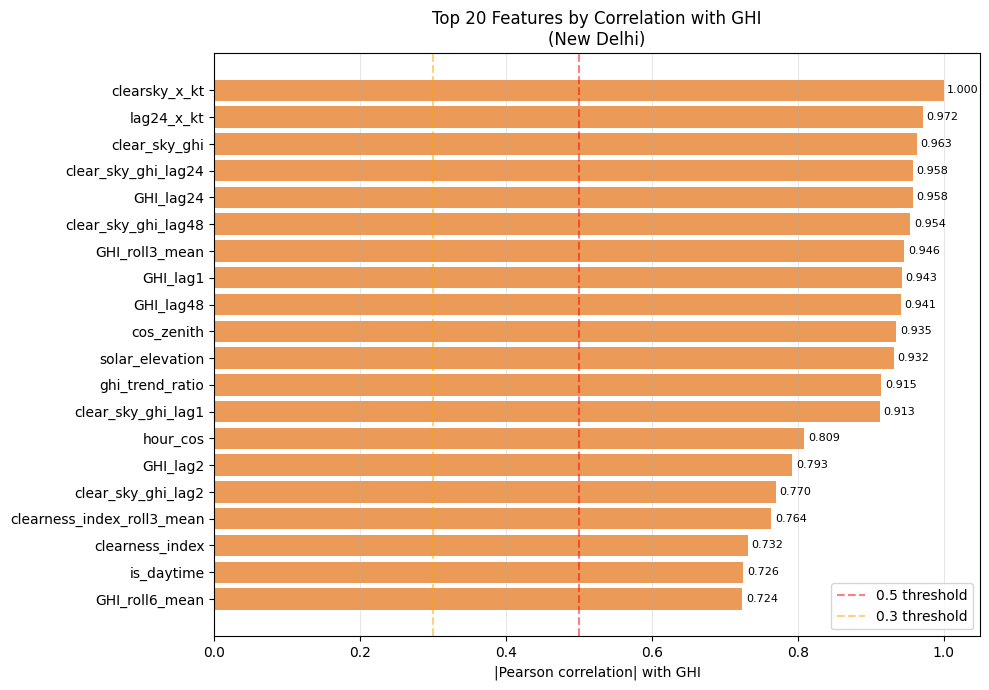

💾 Saved → ..\outputs/plots\04_feature_correlation_ghi.png

🏆 Top 5 features by |correlation| with GHI:
   clearsky_x_kt                        r = 1.0000
   lag24_x_kt                           r = 0.9717
   clear_sky_ghi                        r = 0.9630
   clear_sky_ghi_lag24                  r = 0.9580
   GHI_lag24                            r = 0.9578


In [10]:
city      = "new_delhi"
df        = city_dfs[city]
num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols  = [c for c in num_cols if c != "GHI"]

corr_with_ghi = (
    df[num_cols + ["GHI"]]
    .corr()["GHI"]
    .drop("GHI")
    .abs()
    .sort_values(ascending=False)
)

top20 = corr_with_ghi.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ["#E8883A" if v > 0.5 else "#4A90E8" if v > 0.3
           else "#AAB0B8" for v in top20.values]
bars    = ax.barh(top20.index[::-1], top20.values[::-1],
                  color=colors[::-1], alpha=0.85)
ax.axvline(x=0.5, color="red",    linestyle="--",
           alpha=0.5, label="0.5 threshold")
ax.axvline(x=0.3, color="orange", linestyle="--",
           alpha=0.5, label="0.3 threshold")
ax.set_xlabel("|Pearson correlation| with GHI")
ax.set_title(f"Top 20 Features by Correlation with GHI\n"
             f"({city.replace('_',' ').title()})")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "04_feature_correlation_ghi.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")
print(f"\n🏆 Top 5 features by |correlation| with GHI:")
for feat, val in top20.head(5).items():
    print(f"   {feat:<35}  r = {val:.4f}")